#CELL 1
# Module 2.5 — Workforce Forecasting

This notebook builds a monthly workforce time series, compares baseline and
Holt-Winters forecasting models, evaluates forecast accuracy, and saves the
next 12-month workforce forecast.

The source IBM HR dataset is a point-in-time snapshot without employment event
dates. The monthly history is therefore synthetic, deterministic, and intended
for demonstration purposes.

In [1]:
#CELL 2
import sys
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.modeling.forecasting import (
    build_monthly_workforce_series,
    calculate_forecast_metrics,
    forecast_baseline,
    forecast_holt_winters,
    load_workforce_data,
    run_forecasting_pipeline,
    train_test_split_time_series,
)

In [2]:
#CELL 3
df = load_workforce_data()

print(f"Employees: {len(df):,}")
print(f"Attrition count: {int(df['attrition_flag'].sum()):,}")
print(f"Attrition rate: {df['attrition_flag'].mean():.2%}")

Employees: 1,470
Attrition count: 237
Attrition rate: 16.12%


In [3]:
#CELL 4
workforce = build_monthly_workforce_series(df)

workforce.head()

,month,headcount,hires,exits,attrition_rate,net_change
0,2021-01-01,1441,5,5,0.000000,0
1,2021-02-01,1439,5,7,0.004858,-2
2,2021-03-01,1437,3,5,0.003475,-2
3,2021-04-01,1439,7,5,0.003479,2
4,2021-05-01,1437,7,9,0.006254,-2


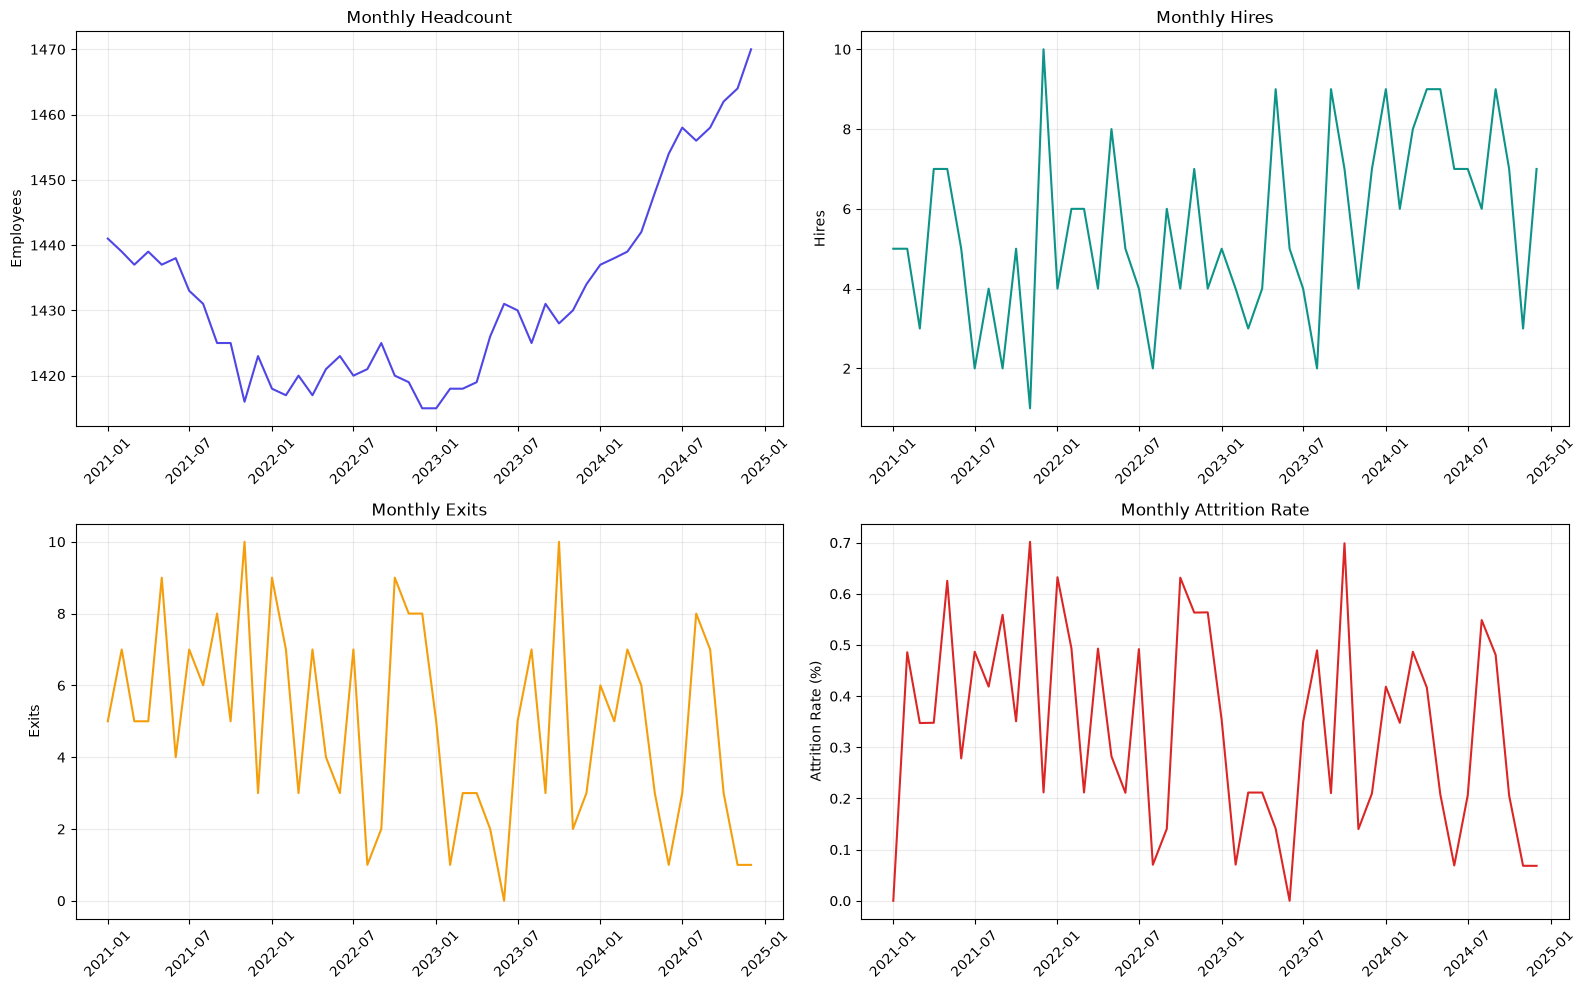

In [4]:
#CELL 5
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(workforce["month"], workforce["headcount"], color="#4f46e5")
axes[0, 0].set_title("Monthly Headcount")
axes[0, 0].set_ylabel("Employees")

axes[0, 1].plot(workforce["month"], workforce["hires"], color="#0d9488")
axes[0, 1].set_title("Monthly Hires")
axes[0, 1].set_ylabel("Hires")

axes[1, 0].plot(workforce["month"], workforce["exits"], color="#f59e0b")
axes[1, 0].set_title("Monthly Exits")
axes[1, 0].set_ylabel("Exits")

axes[1, 1].plot(
    workforce["month"],
    workforce["attrition_rate"] * 100,
    color="#dc2626",
)
axes[1, 1].set_title("Monthly Attrition Rate")
axes[1, 1].set_ylabel("Attrition Rate (%)")

for axis in axes.flat:
    axis.tick_params(axis="x", rotation=45)
    axis.grid(alpha=0.25)

plt.tight_layout()
plt.show()

#CELL 6
## Model validation

The last six months are held out for validation. We compare a naive baseline
against Holt-Winters exponential smoothing using MAE, RMSE, and MAPE.

In [5]:
#CELL 7 
series = workforce.set_index("month")["headcount"]

train, validation = train_test_split_time_series(series, test_periods=6)

baseline_forecast = forecast_baseline(train, horizon=len(validation))
holt_forecast = forecast_holt_winters(train, horizon=len(validation))

baseline_metrics = calculate_forecast_metrics(validation, baseline_forecast)
holt_metrics = calculate_forecast_metrics(validation, holt_forecast)

validation_results = pd.DataFrame(
    [
        {"model": "baseline", **baseline_metrics},
        {"model": "holt_winters", **holt_metrics},
    ]
).sort_values("mae")

validation_results

,model,mae,rmse,mape
1,holt_winters,5.819508,6.652743,0.397584
0,baseline,7.333333,8.717798,0.500792


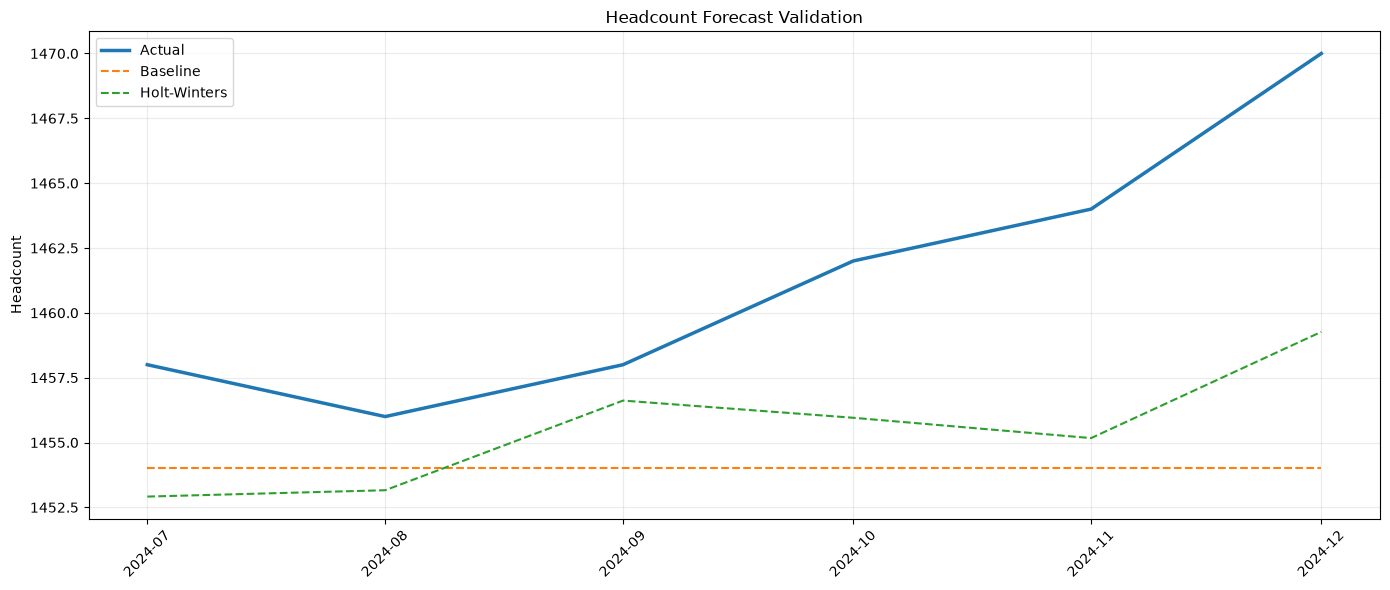

In [6]:
#CELL 8
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(validation.index, validation.values, label="Actual", linewidth=2.5)
ax.plot(
    validation.index,
    baseline_forecast,
    label="Baseline",
    linestyle="--",
)
ax.plot(
    validation.index,
    holt_forecast,
    label="Holt-Winters",
    linestyle="--",
)

ax.set_title("Headcount Forecast Validation")
ax.set_ylabel("Headcount")
ax.legend()
ax.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#CELL 9
## Full forecasting pipeline

The pipeline evaluates models for headcount, hires, exits, and attrition rate.
For each target, it selects the better validation model, refits it on all
available history, and forecasts the next 12 months.

In [7]:
#CELL 10
results = run_forecasting_pipeline(
    test_periods=6,
    forecast_horizon=12,
)

workforce_metrics = results["workforce"]
forecast_results = results["forecasts"]
forecast_metrics = results["metrics"]

print("Validation metrics")
display(forecast_metrics)

print("\nForecast results")
display(forecast_results)

Validation metrics


,target,validation_periods,model,mae,rmse,mape
0,headcount,6,holt_winters,5.819508,6.652743,0.397584
1,headcount,6,baseline,7.333333,8.717798,0.500792
2,hires,6,baseline,1.166667,1.870829,28.703704
3,hires,6,holt_winters,1.666770,1.823293,31.504856
4,exits,6,baseline,2.833333,3.937004,51.091270
5,exits,6,holt_winters,3.484149,3.631119,159.936970
6,attrition_rate,6,baseline,0.001945,0.002699,51.347644
7,attrition_rate,6,holt_winters,0.002515,0.002580,179.337940



Forecast results


,month,target,model,forecast
0,2025-01-01,headcount,holt_winters,1471.143113
1,2025-02-01,headcount,holt_winters,1475.268029
2,2025-03-01,headcount,holt_winters,1479.518450
3,2025-04-01,headcount,holt_winters,1483.894307
4,2025-05-01,headcount,holt_winters,1491.146070
5,2025-06-01,headcount,holt_winters,1498.023374
6,2025-07-01,headcount,holt_winters,1500.026307
7,2025-08-01,headcount,holt_winters,1501.154956
8,2025-09-01,headcount,holt_winters,1505.659254
9,2025-10-01,headcount,holt_winters,1507.539093


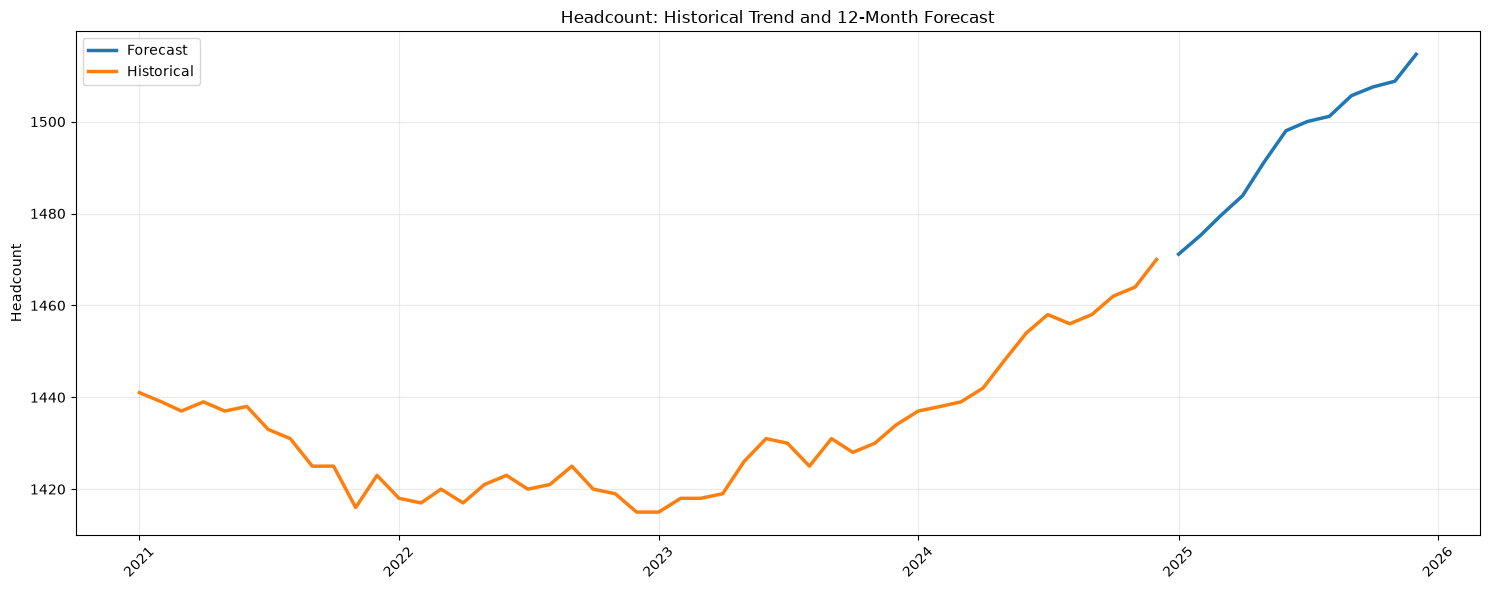

In [8]:
#CELL 11
headcount_forecast = forecast_results[
    forecast_results["target"] == "headcount"
].copy()

historical = workforce_metrics[["month", "headcount"]].rename(
    columns={"headcount": "value"}
)
historical["type"] = "Historical"

future = headcount_forecast[["month", "forecast"]].rename(
    columns={"forecast": "value"}
)
future["type"] = "Forecast"

combined = pd.concat([historical, future], ignore_index=True)

fig, ax = plt.subplots(figsize=(15, 6))

for forecast_type, group in combined.groupby("type"):
    ax.plot(
        group["month"],
        group["value"],
        label=forecast_type,
        linewidth=2.5,
    )

ax.set_title("Headcount: Historical Trend and 12-Month Forecast")
ax.set_ylabel("Headcount")
ax.legend()
ax.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
#CELL 12
headcount_forecast[["month", "model", "forecast"]]

,month,model,forecast
0,2025-01-01,holt_winters,1471.143113
1,2025-02-01,holt_winters,1475.268029
2,2025-03-01,holt_winters,1479.518450
3,2025-04-01,holt_winters,1483.894307
4,2025-05-01,holt_winters,1491.146070
5,2025-06-01,holt_winters,1498.023374
6,2025-07-01,holt_winters,1500.026307
7,2025-08-01,holt_winters,1501.154956
8,2025-09-01,holt_winters,1505.659254
9,2025-10-01,holt_winters,1507.539093


#CELL 13
## Artifacts saved

- `reports/forecasting/monthly_workforce_metrics.csv`
- `reports/forecasting/forecast_results.csv`
- `reports/forecasting/forecast_metrics.csv`
- `models/forecasting/forecast_metadata.json`

Forecast estimates are planning inputs, not guarantees. They should be reviewed
alongside hiring plans, business changes, and HR judgment.